# Evaluación del modelo clasificador de riesgo IA

En este notebook evaluamos el modelo entrenado sobre el conjunto de test.

Métricas:
1. Classification report (precision, recall, f1 por clase)
2. F1-score macro
3. Matriz de confusión
4. Curva ROC multiclase (One-vs-Rest)
5. Análisis de errores
6. Registro de métricas en MLflow

In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Carga del modelo y datos de test

In [3]:
import pandas as pd
import joblib

modelo = joblib.load("model/modelo_baseline.joblib")
tfidf = joblib.load("model/tfidf_vectorizer.joblib")
print("Modelo baseline y vectorizador cargados correctamente.")

test_df = pd.read_csv("data/processed/test.csv")
X_test = test_df["text_final"]
y_test = test_df["etiqueta"]

print(f"Test: {len(X_test)} muestras")
print(f"Clases: {sorted(y_test.unique())}")

Modelo baseline y vectorizador cargados correctamente.
Test: 45 muestras
Clases: ['alto_riesgo', 'inaceptable', 'riesgo_limitado', 'riesgo_minimo']


## 2. Classification report y F1-score macro

In [4]:
from functions import evaluar_modelo

y_pred, report_dict = evaluar_modelo(modelo, tfidf, X_test, y_test)

=== Resultados en TEST ===

                 precision    recall  f1-score   support

    alto_riesgo       0.93      1.00      0.96        13
    inaceptable       0.92      1.00      0.96        12
riesgo_limitado       1.00      1.00      1.00        10
  riesgo_minimo       1.00      0.80      0.89        10

       accuracy                           0.96        45
      macro avg       0.96      0.95      0.95        45
   weighted avg       0.96      0.96      0.95        45

F1-score macro (test): 0.9530



## 3. Matriz de confusión

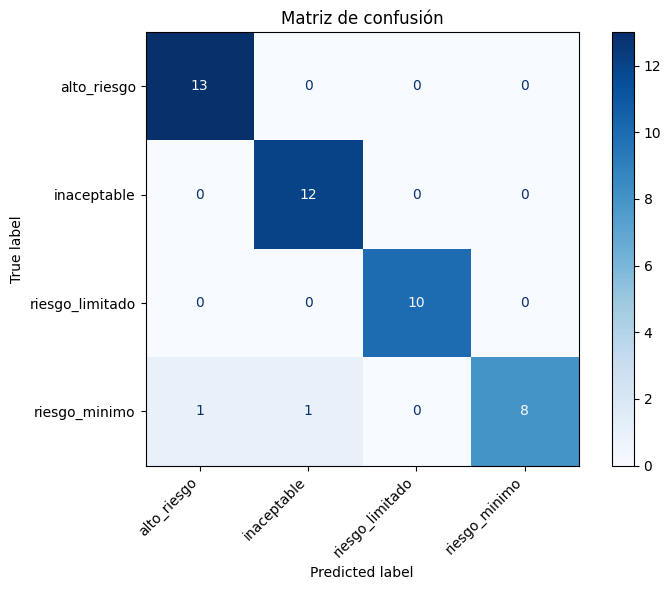

In [5]:
from functions import mostrar_matriz_confusion

clases = sorted(y_test.unique())
fig_cm = mostrar_matriz_confusion(y_test, y_pred, labels=clases)

## 4. Curva ROC multiclase

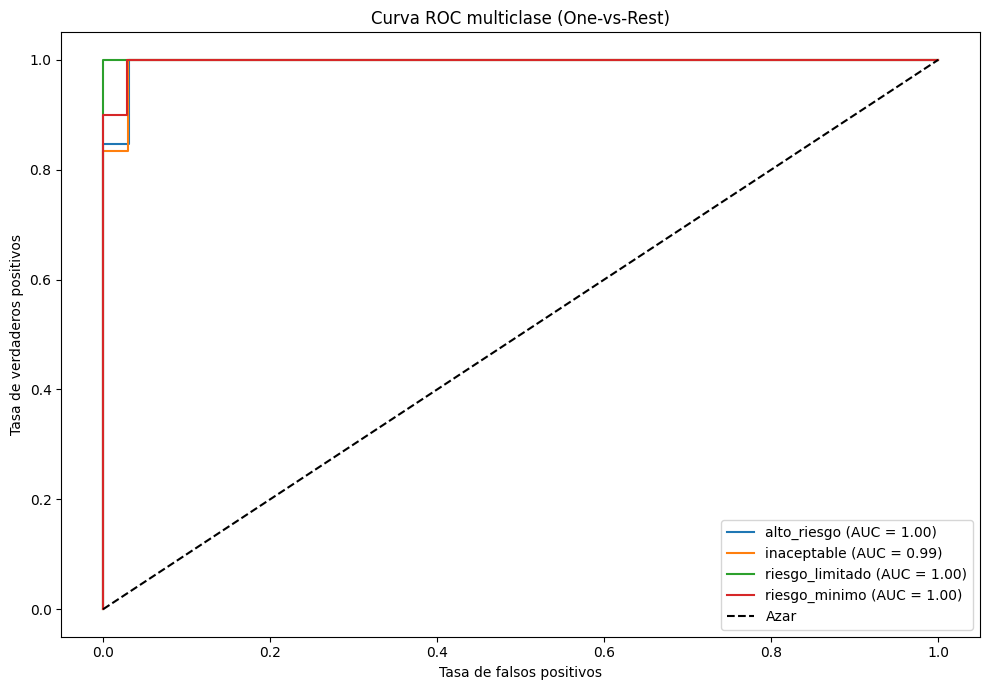


ROC AUC macro: 0.9968
  alto_riesgo: 0.9952
  inaceptable: 0.9949
  riesgo_limitado: 1.0000
  riesgo_minimo: 0.9971


In [6]:
from functions import plot_curva_roc_multiclase

fig_roc, roc_auc_dict = plot_curva_roc_multiclase(modelo, tfidf, X_test, y_test)

## 5. Análisis de errores

In [7]:
from functions import analisis_errores

df_errores = analisis_errores(modelo, tfidf, X_test, y_test)

Total de errores: 2 de 45 (4.4%)

Confusiones más frecuentes:
etiqueta_real  etiqueta_predicha
riesgo_minimo  alto_riesgo          1
               inaceptable          1
dtype: int64

Ejemplos mal clasificados:
  Real: riesgo_minimo | Predicho: inaceptable
  Texto: sistema reconocimiento imagen satelital monitorizar cultivo agrícola detectar zona afectado plaga sequía orientar inspec...

  Real: riesgo_minimo | Predicho: alto_riesgo
  Texto: algoritmo detección spam correos phishing filtrar automáticamente carpeta deseado usuario posibilidad revisión...



## 6. Registro de métricas en MLflow

In [ ]:
import os
os.environ["MLFLOW_TRACKING_INSECURE_TLS"] = "true"
import mlflow
import numpy as np
from functions import MLFLOW_TRACKING_URI, MLFLOW_EXPERIMENT

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

with mlflow.start_run(run_name="evaluacion_test"):
    # Métricas globales
    mlflow.log_metric("test_f1_macro", report_dict["macro avg"]["f1-score"])
    mlflow.log_metric("test_accuracy", report_dict["accuracy"])
    mlflow.log_metric("test_precision_macro", report_dict["macro avg"]["precision"])
    mlflow.log_metric("test_recall_macro", report_dict["macro avg"]["recall"])

    # ROC AUC por clase
    for clase, auc_val in roc_auc_dict.items():
        mlflow.log_metric(f"test_roc_auc_{clase}", auc_val)
    mlflow.log_metric("test_roc_auc_macro", np.mean(list(roc_auc_dict.values())))

    # Guardar la matriz de confusión como imagen
    fig_cm.savefig("model/matriz_confusion.png", dpi=150, bbox_inches="tight")
    mlflow.log_artifact("model/matriz_confusion.png")

    # Guardar la curva ROC como imagen
    fig_roc.savefig("model/curva_roc.png", dpi=150, bbox_inches="tight")
    mlflow.log_artifact("model/curva_roc.png")

    print("Métricas de test registradas en MLflow:")
    print(f"  F1-score macro: {report_dict['macro avg']['f1-score']:.4f}")
    print(f"  Accuracy: {report_dict['accuracy']:.4f}")
    print(f"  ROC AUC macro: {np.mean(list(roc_auc_dict.values())):.4f}")
    print(f"  Run ID: {mlflow.active_run().info.run_id}")

## 7. Conclusiones

Documentar aquí las conclusiones tras observar las métricas:
- ¿Qué clases se confunden más entre sí?
- ¿El modelo generaliza bien o muestra signos de overfitting?
- ¿Qué mejoras se podrían probar en iteraciones futuras?